In [1]:
import os
import pandas as pd
from datasets import Dataset, DatasetDict

data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

urls = {
    "train": "https://huggingface.co/datasets/TimSchopf/arxiv_categories/resolve/main/data/train-00000-of-00001.parquet",
    "validation": "https://huggingface.co/datasets/TimSchopf/arxiv_categories/resolve/main/data/validation-00000-of-00001.parquet",
    "test": "https://huggingface.co/datasets/TimSchopf/arxiv_categories/resolve/main/data/test-00000-of-00001.parquet",
    "descriptions": "https://huggingface.co/datasets/TimSchopf/arxiv_categories/resolve/main/arxiv_category_descriptions/arxiv_category_descriptions-00000-of-00001.parquet"
}

dfs = {}

for name, url in urls.items():
    local_path = os.path.join(data_dir, f"{name}.parquet")
    if not os.path.exists(local_path):
        print(f"Скачиваем {name}...")
        pd.read_parquet(url).to_parquet(local_path)
    
    dfs[name] = pd.read_parquet(local_path)

dfs["descriptions"].to_csv(os.path.join(data_dir, "category_descriptions.csv"), index=False)
del dfs["descriptions"]

dataset = DatasetDict({
    split: Dataset.from_pandas(df) for split, df in dfs.items()
})

print("Ячейка 1 выполнена. Датасет загружен:")
print(dataset)

Ячейка 1 выполнена. Датасет загружен:
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'creation_date'],
        num_rows: 163168
    })
    validation: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'creation_date'],
        num_rows: 20396
    })
    test: Dataset({
        features: ['id', 'title', 'abstract', 'categories', 'creation_date'],
        num_rows: 20397
    })
})


In [2]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import json

# 1. Функция для извлечения листовых категорий
def extract_leaves(examples):
    leaves_batch = []
    for categories in examples['categories']:
        # Бьем строку по '->' и забираем последний элемент
        leaves = [cat.split("->")[-1] for cat in categories]
        leaves_batch.append(leaves)
    return {"leaf_categories": leaves_batch}

print("Извлекаем листовые категории...")
dataset = dataset.map(extract_leaves, batched=True)

# 2. Обучаем бинаризатор на тренировочной выборке
mlb = MultiLabelBinarizer()
mlb.fit(dataset['train']['leaf_categories'])

num_labels = len(mlb.classes_)
print(f"Количество уникальных классов (листьев): {num_labels}")

# 3. Функция для создания multi-hot векторов
def encode_labels(examples):
    multi_hot = mlb.transform(examples['leaf_categories'])
    # Trainer ожидает колонку 'labels' с типом float32 для мультилэйбла
    return {"labels": multi_hot.astype(np.float32)}

print("Преобразуем классы в векторы (multi-hot)...")
dataset = dataset.map(encode_labels, batched=True)

print("\nЯчейка 2 выполнена. Пример обработанных лейблов первой статьи (Train):")
print("Оригинал:", dataset['train'][0]['categories'])
print("Листовые категории:", dataset['train'][0]['leaf_categories'])
print("Размерность вектора labels:", len(dataset['train'][0]['labels']))


classes_list = list(mlb.classes_)

with open("./data/classes.json", "w", encoding="utf-8") as f:
    json.dump(classes_list, f, ensure_ascii=False, indent=2)
    
print("Готово! Файл classes.json сохранен в папке data.")

Извлекаем листовые категории...


Map: 100%|██████████| 20397/20397 [00:00<00:00, 159999.44 examples/s]


Количество уникальных классов (листьев): 130
Преобразуем классы в векторы (multi-hot)...


Map: 100%|██████████| 20397/20397 [00:00<00:00, 143982.47 examples/s]



Ячейка 2 выполнена. Пример обработанных лейблов первой статьи (Train):
Оригинал: ['Computer Science Archive->cs.CV']
Листовые категории: ['cs.CV']
Размерность вектора labels: 130
Готово! Файл classes.json сохранен в папке data.


In [3]:
import os
from transformers import AutoTokenizer
from datasets import load_from_disk

model_checkpoint = "allenai/scibert_scivocab_uncased"
cache_dir = "./data/model_cache"
tokenized_dir = "./data/tokenized_dataset"

print(f"Загружаем токенизатор {model_checkpoint}...")
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, cache_dir=cache_dir)

if os.path.exists(tokenized_dir):
    print(f"Найдена сохраненная токенизация. Загружаем из {tokenized_dir}...")
    tokenized_dataset = load_from_disk(tokenized_dir)
else:
    print("Сохраненных данных нет. Токенизируем тексты")
    
    def tokenize_function(examples):
        texts = [f"{t}. {a}" for t, a in zip(examples['title'], examples['abstract'])]
        return tokenizer(texts, padding="max_length", truncation=True, max_length=512)

    cols_to_remove = ['id', 'title', 'abstract', 'categories', 'leaf_categories', 'creation_date']

    tokenized_dataset = dataset.map(
        tokenize_function, 
        batched=True, 
        remove_columns=cols_to_remove
    )
    
    print(f"Сохраняем токенизированный датасет на диск в {tokenized_dir}...")
    tokenized_dataset.save_to_disk(tokenized_dir)

print("\nЯчейка 3 выполнена. Итоговый датасет:")
print(tokenized_dataset)

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Загружаем токенизатор allenai/scibert_scivocab_uncased...
Найдена сохраненная токенизация. Загружаем из ./data/tokenized_dataset...

Ячейка 3 выполнена. Итоговый датасет:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 163168
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20396
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20397
    })
})


In [4]:
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EvalPrediction
from sklearn.metrics import f1_score

checkpoint_dir = "./data/scibert-arxiv"

print("1. Загружаем модель SciBERT (из локального кэша, если уже скачана)...")
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    problem_type="multi_label_classification",
    cache_dir=cache_dir
)

print("2. Определяем функцию для подсчета метрик (F1-score)...")
def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    probs = torch.sigmoid(torch.tensor(preds)).numpy()
    
    y_pred = (probs > 0.5).astype(int)
    y_true = p.label_ids
    
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    
    return {'macro_f1': macro_f1, 'micro_f1': micro_f1}

print("3. Настраиваем аргументы обучения (Оптимизация под A100)...")
args = TrainingArguments(
    output_dir=checkpoint_dir,
    evaluation_strategy="epoch",  
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=128,  # Увеличили батч для A100
    per_device_eval_batch_size=128,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio = 0.1,
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    save_total_limit=2,
    fp16=False,                      # Выключаем старый формат
    bf16=True,                       # Включаем Bfloat16 (идеально для A100)
    report_to="none"
)

print("4. Инициализируем Trainer на полных данных...")
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],      # Полный датасет (163к)
    eval_dataset=tokenized_dataset["validation"],  # Полный датасет (20к)
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("\nЯчейка 4 выполнена. Пайплайн собран чисто.")

2026-04-08 14:36:36.240747: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


1. Загружаем модель SciBERT (из локального кэша, если уже скачана)...


/usr/local/lib/python3.10/dist-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


2. Определяем функцию для подсчета метрик (F1-score)...
3. Настраиваем аргументы обучения (Оптимизация под A100)...
4. Инициализируем Trainer на полных данных...

Ячейка 4 выполнена. Пайплайн собран чисто.


In [5]:
import os

last_checkpoint = None
if os.path.exists(checkpoint_dir) and os.listdir(checkpoint_dir):
    last_checkpoint = True
    print(f"Найдены существующие чекпоинты в {checkpoint_dir}. Продолжаем обучение...")
else:
    print("Чекпоинты не найдены. Начинаем обучение с нуля.")

trainer.train(resume_from_checkpoint=last_checkpoint)

Найдены существующие чекпоинты в ./data/scibert-arxiv. Продолжаем обучение...


  0%|          | 0/12750 [00:05<?, ?it/s]

{'train_runtime': 5.5575, 'train_samples_per_second': 293600.868, 'train_steps_per_second': 2294.207, 'train_loss': 0.0, 'epoch': 10.0}


TrainOutput(global_step=12750, training_loss=0.0, metrics={'train_runtime': 5.5575, 'train_samples_per_second': 293600.868, 'train_steps_per_second': 2294.207, 'train_loss': 0.0, 'epoch': 10.0})

In [6]:
train_metrics = trainer.evaluate(tokenized_dataset["train"].select(range(5000)))
print("train_metrics")
print(train_metrics)

100%|██████████| 40/40 [00:11<00:00,  3.52it/s]

train_metrics
{'eval_loss': 0.011888702400028706, 'eval_macro_f1': 0.5814433736928112, 'eval_micro_f1': 0.8060639384180346, 'eval_runtime': 12.7891, 'eval_samples_per_second': 390.957, 'eval_steps_per_second': 3.128, 'epoch': 10.0}


In [7]:
test_metrics = trainer.evaluate(tokenized_dataset["test"])
print("test_metrics")
print(test_metrics)

100%|██████████| 160/160 [00:47<00:00,  3.37it/s]

test_metrics
{'eval_loss': 0.016583576798439026, 'eval_macro_f1': 0.4941390157457544, 'eval_micro_f1': 0.7041771240685616, 'eval_runtime': 47.8621, 'eval_samples_per_second': 426.162, 'eval_steps_per_second': 3.343, 'epoch': 10.0}


In [8]:
eval_metrics = trainer.evaluate(tokenized_dataset["validation"])
print("eval_metrics")
print(eval_metrics)

100%|██████████| 160/160 [00:47<00:00,  3.37it/s]

eval_metrics
{'eval_loss': 0.016634542495012283, 'eval_macro_f1': 0.4921254802980877, 'eval_micro_f1': 0.7037540277184674, 'eval_runtime': 47.8617, 'eval_samples_per_second': 426.144, 'eval_steps_per_second': 3.343, 'epoch': 10.0}


Получаем предсказания на валидационной выборке...


100%|██████████| 160/160 [00:47<00:00,  3.39it/s]

Подбираем оптимальный порог и считаем метрики...


------------------------------
Дефолт (0.50): Micro-F1 = 0.7038 | Macro-F1 = 0.4921
Лучший Micro: Порог 0.30 -> F1 = 0.7144
Лучший Macro: Порог 0.20 -> F1 = 0.5543


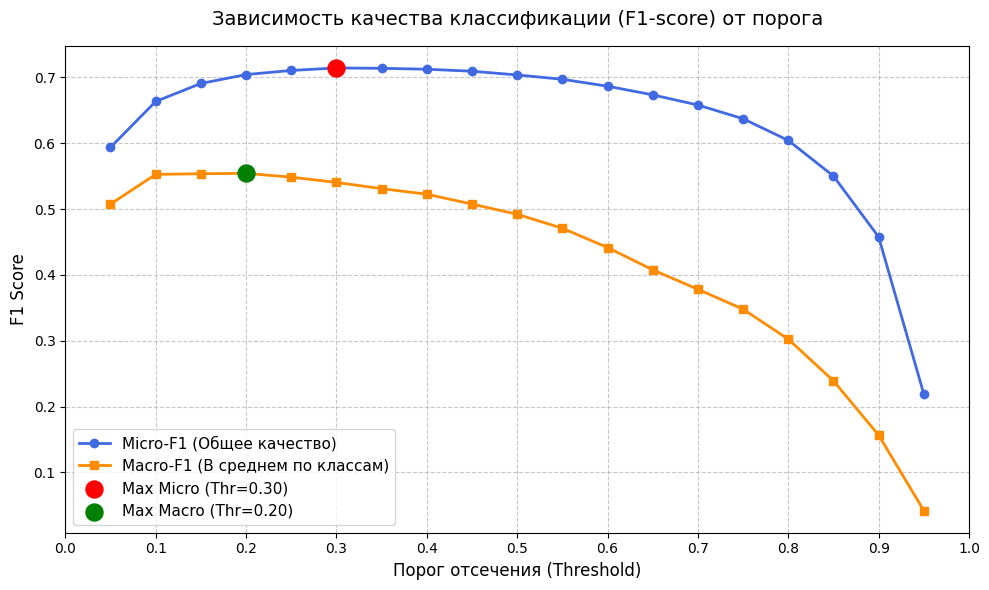

In [10]:
import numpy as np
from sklearn.metrics import f1_score
import torch
import matplotlib.pyplot as plt

print("Получаем предсказания на валидационной выборке...")
preds = trainer.predict(tokenized_dataset["validation"])
# Переводим сырые логиты в вероятности
probs = torch.sigmoid(torch.tensor(preds.predictions)).numpy()
y_true = preds.label_ids

# Списки для хранения данных для графика
# Шаг 0.05 от 0.05 до 0.95 включительно
thresholds = np.arange(0.05, 0.96, 0.05) 
micro_f1_scores = []
macro_f1_scores = []

best_micro_thresh, best_micro_f1 = 0.5, 0.0
best_macro_thresh, best_macro_f1 = 0.5, 0.0

print("Подбираем оптимальный порог и считаем метрики...")
for thresh in thresholds:
    # Превращаем вероятности в 1 или 0 по текущему порогу
    y_pred = (probs > thresh).astype(int)
    
    micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    # Сохраняем для графика
    micro_f1_scores.append(micro)
    macro_f1_scores.append(macro)
    
    # Обновляем лучшие значения
    if micro > best_micro_f1:
        best_micro_f1 = micro
        best_micro_thresh = thresh
        
    if macro > best_macro_f1:
        best_macro_f1 = macro
        best_macro_thresh = thresh

print("-" * 30)
print(f"Дефолт (0.50): Micro-F1 = {f1_score(y_true, (probs > 0.5).astype(int), average='micro', zero_division=0):.4f} | Macro-F1 = {f1_score(y_true, (probs > 0.5).astype(int), average='macro', zero_division=0):.4f}")
print(f"Лучший Micro: Порог {best_micro_thresh:.2f} -> F1 = {best_micro_f1:.4f}")
print(f"Лучший Macro: Порог {best_macro_thresh:.2f} -> F1 = {best_macro_f1:.4f}")

# --- Отрисовка графика ---
plt.figure(figsize=(10, 6))

# Рисуем линии
plt.plot(thresholds, micro_f1_scores, label='Micro-F1 (Общее качество)', marker='o', color='royalblue', linewidth=2)
plt.plot(thresholds, macro_f1_scores, label='Macro-F1 (В среднем по классам)', marker='s', color='darkorange', linewidth=2)

# Отмечаем точки максимума красным и зеленым цветом
plt.scatter(best_micro_thresh, best_micro_f1, color='red', s=150, zorder=5, label=f'Max Micro (Thr={best_micro_thresh:.2f})')
plt.scatter(best_macro_thresh, best_macro_f1, color='green', s=150, zorder=5, label=f'Max Macro (Thr={best_macro_thresh:.2f})')

# Оформление графика
plt.title('Зависимость качества классификации (F1-score) от порога', fontsize=14, pad=15)
plt.xlabel('Порог отсечения (Threshold)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.xticks(np.arange(0, 1.05, 0.1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

# Показываем график в ячейке
plt.show()

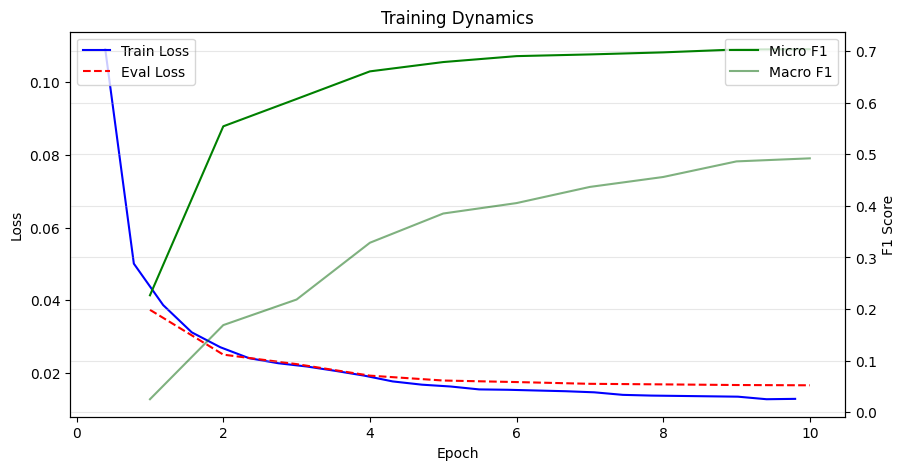

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Укажи путь к последнему чекпоинту (где лежит файл trainer_state.json)
checkpoint_path = Path("./data/scibert-arxiv/checkpoint-12750") # замени XXXX на номер шага

def plot_trainer_history(state_json_path):
    with open(state_json_path, "r") as f:
        data = json.load(f)
    
    # Превращаем лог в таблицу
    df = pd.DataFrame(data["log_history"])
    
    # Разделяем логи обучения и валидации
    train_df = df[df['loss'].notna()]
    eval_df = df[df['eval_loss'].notna()]
    
    # Рисуем графики
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Лосс
    ax1.plot(train_df['epoch'], train_df['loss'], label='Train Loss', color='blue')
    ax1.plot(eval_df['epoch'], eval_df['eval_loss'], label='Eval Loss', color='red', linestyle='--')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')

    # Метрики (F1)
    ax2 = ax1.twinx()
    ax2.plot(eval_df['epoch'], eval_df['eval_micro_f1'], label='Micro F1', color='green')
    ax2.plot(eval_df['epoch'], eval_df['eval_macro_f1'], label='Macro F1', color='darkgreen', alpha=0.5)
    ax2.set_ylabel('F1 Score')
    ax2.legend(loc='upper right')

    plt.title('Training Dynamics')
    plt.grid(True, alpha=0.3)
    plt.show()

# Запуск
plot_trainer_history(checkpoint_path / "trainer_state.json")